## Librerias

In [2]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [4]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [5]:
# Cuantos partidos se jugaron?
# Completar

len(mundial)

64

In [6]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar

mundial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     object 
 2   date                             64 non-null     object 
 3   hour                             64 non-null     object 
 4   venue                            64 non-null     object 
 5   referee                          64 non-null     object 
 6   group                            64 non-null     object 
 7   1                                64 non-null     object 
 8   2                                64 non-null     object 
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                  

## Analisis

### Primera Parte

In [6]:
# Cuantas selecciones participaron?
# Completar

selecciones = set(mundial["1"]).union(set(mundial["2"]))
len(selecciones)

32

In [7]:
# Cuantas fases tiene el mundial?
# Completar

mundial["group"].unique()

array(['Group A', 'Group B', 'Group C', 'Group D', 'Group F', 'Group E',
       'Group G', 'Group H', 'Round of 16', 'Quarter-final', 'Semi-Final',
       'Play-off for third place', 'Final'], dtype=object)

In [11]:
# Cual fue la "attendance" promedio por partido?
# Completar
mundial["attendance"].mean()

np.float64(53191.4375)

In [13]:
# Cual fue el partido con mas diferencia de goles?
# Completar

mundial["dif_goles"] = abs(mundial["1_goals"] - mundial["2_goals"])
mundial.loc[mundial["dif_goles"].idxmax()]

match_no                                                11
day_of_week                                            Wed
date                                             23-Nov-22
hour                                                 17:00
venue                                   Al Thumama Stadium
referee                            Mohammed Abdulla Hassan
group                                              Group E
1                                                    SPAIN
2                                               COSTA RICA
attendance                                           40013
1_xg                                                   3.5
2_xg                                                   0.0
1_poss                                                  81
2_poss                                                  19
1_goals                                                  7
2_goals                                                  0
score                                                  7

In [14]:
# Cual es la selección que mas penales metió?
# Completar

penales_local = mundial.groupby("1")["1_panelties_scored"].sum()
penales_visitante = mundial.groupby("2")["2_panelties_scored"].sum()
penales_total = penales_local.add(penales_visitante, fill_value=0)
penales_total.idxmax()

'ARGENTINA'

In [15]:
# Cual es la selección que mas penales le hicieron?
# Completar

penales_contra_local = mundial.groupby("1")["2_panelties_scored"].sum()
penales_contra_visitante = mundial.groupby("2")["1_panelties_scored"].sum()
penales_contra = penales_contra_local.add(penales_contra_visitante, fill_value=0)
penales_contra.idxmax()

'FRANCE'

### Segunda Parte

In [7]:
equipo : str = "ARGENTINA"

In [8]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial["1"] == equipo

In [9]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial["2"] == equipo

In [10]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = mundial[filtroLocal | filtroVisitante]
partidos


,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [12]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles_local = mundial.loc[filtroLocal, "1_goals"].sum()
goles_visitante = mundial.loc[filtroVisitante, "2_goals"].sum()
goles : int = goles_local + goles_visitante
goles

np.int64(15)

In [13]:
# Cuantos goles hizo el equipo en promedio
# Completar

goles / len(partidos)

np.float64(2.142857142857143)

In [14]:
# Cuantos partidos gano el equipo
# Completar

ganados_local = ((mundial["1"] == equipo) & (mundial["1_goals"] > mundial["2_goals"])).sum()
ganados_visitante = ((mundial["2"] == equipo) & (mundial["2_goals"] > mundial["1_goals"])).sum()
ganados : int = ganados_local + ganados_visitante
ganados

np.int64(4)

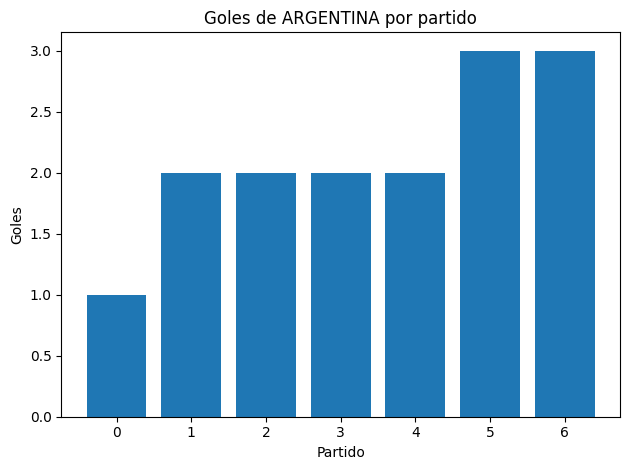

In [15]:
# Graficar los goles hechos por el equipo en cada partido

goles_por_partido = []
for _, row in partidos.iterrows():
    if row["1"] == equipo:
        goles_por_partido.append(row["1_goals"])
    else:
        goles_por_partido.append(row["2_goals"])

fig, ax = plt.subplots()
ax.bar(range(len(partidos)), goles_por_partido)
ax.set_xlabel("Partido")
ax.set_ylabel("Goles")
ax.set_title(f"Goles de {equipo} por partido")
plt.tight_layout()
plt.show()
# Completar

### Tercera Parte

In [16]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

goles_como_local = mundial.groupby("1")["1_goals"].sum()
goles_como_visitante = mundial.groupby("2")["2_goals"].sum()
equipos = goles_como_local.add(goles_como_visitante, fill_value=0).sort_values(ascending=False)
goles = equipos
goles

1
FRANCE            16
ARGENTINA         15
ENGLAND           13
PORTUGAL          12
NETHERLANDS       10
SPAIN              9
BRAZIL             8
CROATIA            8
GERMANY            6
MOROCCO            6
JAPAN              5
SWITZERLAND        5
SERBIA             5
SENEGAL            5
KOREA REPUBLIC     5
GHANA              5
IRAN               4
AUSTRALIA          4
ECUADOR            4
CAMEROON           4
UNITED STATES      3
COSTA RICA         3
SAUDI ARABIA       3
POLAND             3
CANADA             2
MEXICO             2
URUGUAY            2
QATAR              1
DENMARK            1
BELGIUM            1
TUNISIA            1
WALES              1
dtype: int64

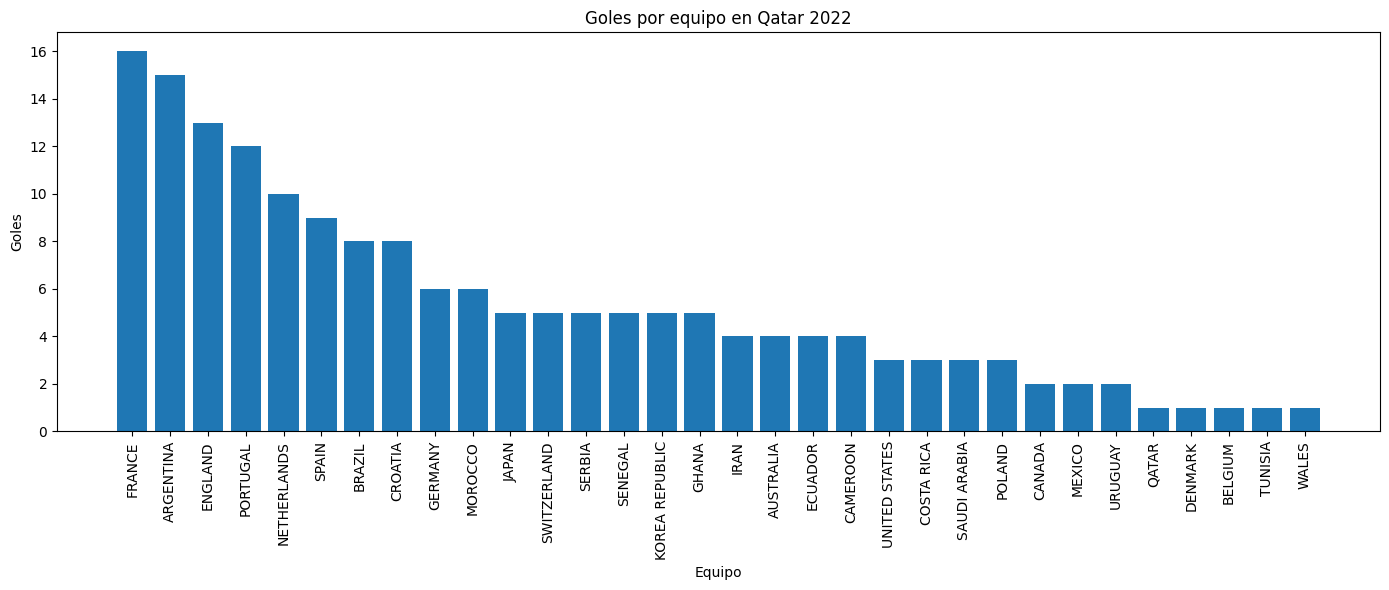

In [17]:
# Graficar los goles por equipo en todo el mundial

# Gráfico de goles por equipo
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(equipos.index, equipos.values)
ax.set_xlabel("Equipo")
ax.set_ylabel("Goles")
ax.set_title("Goles por equipo en Qatar 2022")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show() 

# Completar

In [18]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar

# ¿Qué equipo hizo más goles?
equipos.idxmax()

'FRANCE'

In [19]:
# Por cada partido, cual fue la diferencia de goles?
# Completar

# Diferencia de goles por partido
mundial["dif_goles"] = abs(mundial["1_goals"] - mundial["2_goals"])
mundial[["match_no", "1", "2", "1_goals", "2_goals", "dif_goles"]]

,match_no,1,2,1_goals,2_goals,dif_goles
0,1,QATAR,ECUADOR,0,2,2
1,2,ENGLAND,IRAN,6,2,4
2,3,SENEGAL,NETHERLANDS,0,2,2
3,4,UNITED STATES,WALES,1,1,0
4,5,ARGENTINA,SAUDI ARABIA,1,2,1
...,...,...,...,...,...,...
59,60,ENGLAND,FRANCE,1,2,1
60,61,ARGENTINA,CROATIA,3,0,3
61,62,FRANCE,MOROCCO,2,0,2
62,63,CROATIA,MOROCCO,2,1,1


In [20]:
# Por cada partido, cual fue el equipo que gano?
# Completar

# Ganador de cada partido
def ganador(row):
    if row["1_goals"] > row["2_goals"]:
        return row["1"]
    elif row["2_goals"] > row["1_goals"]:
        return row["2"]
    else:
        return "Empate"

mundial["ganador"] = mundial.apply(ganador, axis=1)
mundial[["match_no", "1", "2", "1_goals", "2_goals", "ganador"]]

,match_no,1,2,1_goals,2_goals,ganador
0,1,QATAR,ECUADOR,0,2,ECUADOR
1,2,ENGLAND,IRAN,6,2,ENGLAND
2,3,SENEGAL,NETHERLANDS,0,2,NETHERLANDS
3,4,UNITED STATES,WALES,1,1,Empate
4,5,ARGENTINA,SAUDI ARABIA,1,2,SAUDI ARABIA
...,...,...,...,...,...,...
59,60,ENGLAND,FRANCE,1,2,FRANCE
60,61,ARGENTINA,CROATIA,3,0,ARGENTINA
61,62,FRANCE,MOROCCO,2,0,FRANCE
62,63,CROATIA,MOROCCO,2,1,CROATIA


In [21]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar

# En cada fase, ¿qué equipo hizo más goles?
goles_local_fase = mundial.groupby(["group", "1"])["1_goals"].sum().reset_index()
goles_local_fase.columns = ["group", "equipo", "goles"]
goles_visitante_fase = mundial.groupby(["group", "2"])["2_goals"].sum().reset_index()
goles_visitante_fase.columns = ["group", "equipo", "goles"]

goles_por_fase = pd.concat([goles_local_fase, goles_visitante_fase])
goles_por_fase = goles_por_fase.groupby(["group", "equipo"])["goles"].sum().reset_index()
goles_por_fase.loc[goles_por_fase.groupby("group")["goles"].idxmax()]

,group,equipo,goles
0,Final,ARGENTINA,3
3,Group A,NETHERLANDS,5
6,Group B,ENGLAND,9
10,Group C,ARGENTINA,5
16,Group D,FRANCE,6
21,Group E,SPAIN,9
24,Group F,CROATIA,4
28,Group G,SERBIA,5
32,Group H,PORTUGAL,6
34,Play-off for third place,CROATIA,2


### Tercera Parte

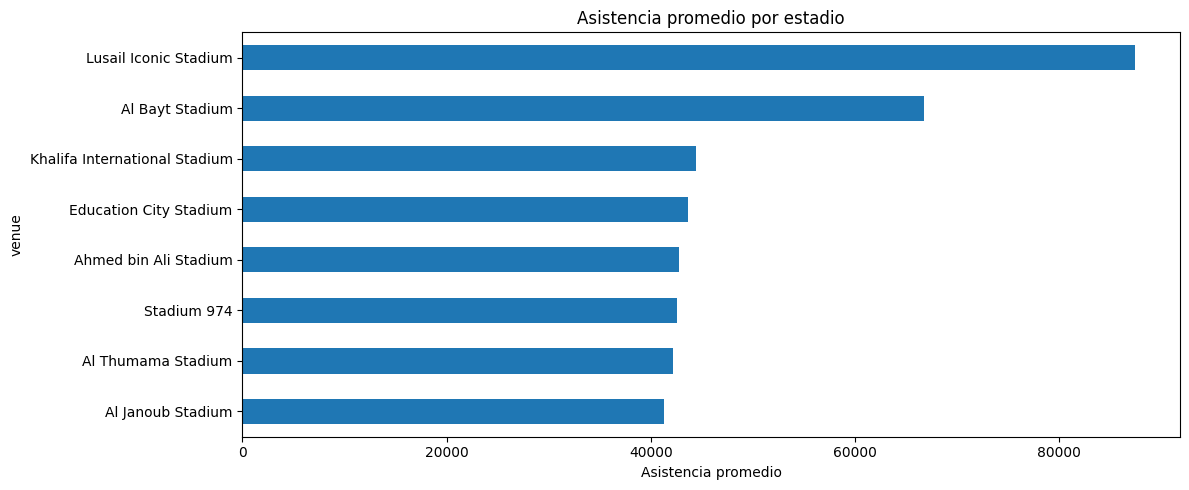

In [22]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar

# Análisis extra: asistencia promedio por estadio
fig, ax = plt.subplots(figsize=(12, 5))
mundial.groupby("venue")["attendance"].mean().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Asistencia promedio por estadio")
ax.set_xlabel("Asistencia promedio")
plt.tight_layout()
plt.show()